# Demeter Data Pipeline Verification & Benchmarking
This notebook verifies the data pipeline from start to finish and provides computational benchmarks comparing the various vision model architectures (Base CNN, Flat CNN, Hierarchical CNN, Hybrid SVM, and Hierarchical Hybrid SVM).

The goal is to analyze 4 key timing metrics (Preprocessing Latency, Inference Latency, Total Latency, and Throughput) for each model to evaluate their suitability for edge-device deployment.

In [1]:
import os
import sys
import time
import warnings

# Suppress slow TensorFlow GPU initialization/logging for CPU
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
warnings.filterwarnings('ignore')

print("Importing libraries...")
start_import = time.time()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import joblib

# Add src to path
sys.path.append(os.path.abspath('..'))

from src.core.inference_engine import extract_hybrid_fft_features

end_import = time.time()
print(f"Imports completed in {end_import - start_import:.2f} seconds.")

Importing libraries...


Imports completed in 21.49 seconds.


In [2]:
# Setup paths
DATA_DIR = os.path.abspath('../data/raw/vision/PlantVillage')
if not os.path.exists(DATA_DIR):
    print("Please ensure raw PlantVillage data is in data/raw/vision/PlantVillage")

# Find a few sample images
sample_images = []
if os.path.exists(DATA_DIR):
    for root, _, files in os.walk(DATA_DIR):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                sample_images.append(os.path.join(root, f))
                if len(sample_images) >= 50: # Limit to 50 for quick benchmarking
                    break
        if len(sample_images) >= 50:
            break

print(f"Loaded {len(sample_images)} images for benchmarking.")

# 1. Base CNN (Custom Baseline CNN from scratch)
try:
    from tensorflow.keras import layers, models
    base_cnn_model = models.Sequential([
        layers.Input(shape=(150, 150, 3)),
        layers.Rescaling(1./255),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(15, activation='softmax')
    ])
    base_cnn_model.predict(np.zeros((1, 150, 150, 3)), verbose=0)
    print("Base CNN model initialized successfully.")
except Exception as e:
    print(f"Failed to build base CNN: {e}")

# 2. Flat CNN (MobileNetV2 backbone trained on our data)
cnn_path = '../models/demeter_cnn_plantvillage.keras'
if os.path.exists(cnn_path):
    print("Loading Flat CNN...")
    flat_cnn_model = tf.keras.models.load_model(cnn_path)
else:
    print(f"Flat CNN model not found at {cnn_path}")

# 3. Hierarchical CNN models
print("Loading Hierarchical CNN models...")
id_model_path = '../models/demeter_cnn_plantvillage_species_identifier.keras'
hier_cnn_models = {}
if os.path.exists(id_model_path):
    identifier_cnn_model = tf.keras.models.load_model(id_model_path)
    for species in ['pepper', 'potato', 'tomato']:
        model_path = f'../models/demeter_cnn_plantvillage_{species}.keras'
        if os.path.exists(model_path):
            hier_cnn_models[species] = tf.keras.models.load_model(model_path)
    print("Loaded Hierarchical CNN models.")
else:
    print("Hierarchical CNN models not found.")

# 4. Hybrid SVM models (Monolithic)
svm_dir = '../models/experimentation'
try:
    svm_model_base = joblib.load(os.path.join(svm_dir, 'hybrid_full_svm.joblib'))
    scaler_fft = joblib.load(os.path.join(svm_dir, 'hybrid_full_fft_scaler.joblib'))
    pca_fft = joblib.load(os.path.join(svm_dir, 'hybrid_full_fft_pca.joblib'))
    scaler_hist = joblib.load(os.path.join(svm_dir, 'hybrid_full_hist_scaler.joblib'))
    print("Loaded monolithic Hybrid SVM components.")
except Exception as e:
    print(f"Monolithic Hybrid SVM components missing: {e}")

# 5. Hierarchical SVM models
try:
    svm_identifier_model = joblib.load(os.path.join(svm_dir, 'hybrid_svm_species_identifier.joblib'))
    identifier_fft_scaler = joblib.load(os.path.join(svm_dir, 'hybrid_svm_species_identifier_fft_scaler.joblib'))
    identifier_hist_scaler = joblib.load(os.path.join(svm_dir, 'hybrid_svm_species_identifier_hist_scaler.joblib'))
    identifier_fft_pca = joblib.load(os.path.join(svm_dir, 'hybrid_svm_species_identifier_fft_pca.joblib'))
    
    svm_hier_models = {}
    species_scaler_fft_dict = {}
    species_scaler_hist_dict = {}
    species_pca_fft_dict = {}
    
    for species in ['pepper', 'potato', 'tomato']:
        model_path = os.path.join(svm_dir, 'species_svms', f'hybrid_svm_{species}.joblib')
        if os.path.exists(model_path):
            svm_hier_models[species] = joblib.load(model_path)
            species_scaler_fft_dict[species] = joblib.load(os.path.join(svm_dir, 'species_svms', f'hybrid_svm_{species}_fft_scaler.joblib'))
            species_scaler_hist_dict[species] = joblib.load(os.path.join(svm_dir, 'species_svms', f'hybrid_svm_{species}_hist_scaler.joblib'))
            species_pca_fft_dict[species] = joblib.load(os.path.join(svm_dir, 'species_svms', f'hybrid_svm_{species}_fft_pca.joblib'))
            
    print("Loaded Hierarchical SVM models and all scaler/PCA components successfully.")
except Exception as e:
    print(f"Hierarchical SVM models missing or failed to load: {e}")


Loaded 50 images for benchmarking.


Base CNN model initialized successfully.
Loading Flat CNN...


Loading Hierarchical CNN models...


Loaded Hierarchical CNN models.


Loaded monolithic Hybrid SVM components.


Loaded Hierarchical SVM models and all scaler/PCA components successfully.


## 2. Base CNN Inference Benchmark
We measure the latency of our custom baseline CNN model.

In [3]:
base_cnn_times = []
base_cnn_prep_times = []
base_cnn_inf_times = []

# Warmup
dummy_img = np.zeros((1, 150, 150, 3))
base_cnn_model.predict(dummy_img, verbose=0)

for img_path in sample_images:
    start_time = time.time()
    
    # Preprocessing
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (150, 150))
    img_array = np.expand_dims(img_resized, axis=0)
    
    prep_time = time.time()
    # Inference
    base_cnn_model.predict(img_array, verbose=0)
    
    end_time = time.time()
    base_cnn_times.append((end_time - start_time) * 1000)
    base_cnn_prep_times.append((prep_time - start_time) * 1000)
    base_cnn_inf_times.append((end_time - prep_time) * 1000)

base_cnn_avg_time = np.mean(base_cnn_times) if base_cnn_times else 0
base_cnn_avg_prep = np.mean(base_cnn_prep_times) if base_cnn_prep_times else 0
base_cnn_avg_inf = np.mean(base_cnn_inf_times) if base_cnn_inf_times else 0
base_cnn_throughput = 1000.0 / base_cnn_avg_time if base_cnn_avg_time else 0

print(f"Base CNN (Custom Baseline) Metrics:")
print(f"  - Preprocessing Latency: {base_cnn_avg_prep:.2f} ms")
print(f"  - Inference Latency: {base_cnn_avg_inf:.2f} ms")
print(f"  - Total Latency: {base_cnn_avg_time:.2f} ms per image")
print(f"  - Throughput: {base_cnn_throughput:.2f} images/sec")

Base CNN (Custom Baseline) Metrics:
  - Preprocessing Latency: 6.18 ms
  - Inference Latency: 386.61 ms
  - Total Latency: 392.79 ms per image
  - Throughput: 2.55 images/sec


## 3. Flat CNN Inference Benchmark
We measure the latency of our production Flat MobileNetV2 CNN model.

In [4]:
flat_cnn_times = []
flat_cnn_prep_times = []
flat_cnn_inf_times = []

# Warmup
dummy_img = np.zeros((1, 150, 150, 3))
flat_cnn_model.predict(dummy_img, verbose=0)

for img_path in sample_images:
    start_time = time.time()
    
    # Preprocessing
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (150, 150))
    img_array = np.expand_dims(img_resized, axis=0)
    
    prep_time = time.time()
    # Inference
    flat_cnn_model.predict(img_array, verbose=0)
    
    end_time = time.time()
    flat_cnn_times.append((end_time - start_time) * 1000)
    flat_cnn_prep_times.append((prep_time - start_time) * 1000)
    flat_cnn_inf_times.append((end_time - prep_time) * 1000)

flat_cnn_avg_time = np.mean(flat_cnn_times) if flat_cnn_times else 0
flat_cnn_avg_prep = np.mean(flat_cnn_prep_times) if flat_cnn_prep_times else 0
flat_cnn_avg_inf = np.mean(flat_cnn_inf_times) if flat_cnn_inf_times else 0
flat_cnn_throughput = 1000.0 / flat_cnn_avg_time if flat_cnn_avg_time else 0

print(f"Flat CNN (MobileNetV2 Backbone) Metrics:")
print(f"  - Preprocessing Latency: {flat_cnn_avg_prep:.2f} ms")
print(f"  - Inference Latency: {flat_cnn_avg_inf:.2f} ms")
print(f"  - Total Latency: {flat_cnn_avg_time:.2f} ms per image")
print(f"  - Throughput: {flat_cnn_throughput:.2f} images/sec")

Flat CNN (MobileNetV2 Backbone) Metrics:
  - Preprocessing Latency: 4.35 ms
  - Inference Latency: 545.46 ms
  - Total Latency: 549.81 ms per image
  - Throughput: 1.82 images/sec


## 4. Hierarchical CNN Inference Benchmark
We measure the latency of our Hierarchical CNN pipeline.

In [5]:
from src.core.inference_engine import predict_hierarchical_cnn

species_names = ['Pepper', 'Potato', 'Tomato']
class_dirs = [
    'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy',
    'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy',
    'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight',
    'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy'
]

hier_cnn_times = []
hier_cnn_prep_times = []
hier_cnn_inf_times = []

# Warmup
dummy_img = np.zeros((1, 224, 224, 3))
predict_hierarchical_cnn(dummy_img, identifier_cnn_model, hier_cnn_models, species_names, class_dirs)

for img_path in sample_images:
    start_time = time.time()
    
    # Preprocessing
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_array = np.expand_dims(img_resized, axis=0)
    
    prep_time = time.time()
    # Inference
    try:
        predict_hierarchical_cnn(img_array, identifier_cnn_model, hier_cnn_models, species_names, class_dirs)
    except Exception as e:
        print(f"Failed on {img_path}: {e}")
        
    end_time = time.time()
    hier_cnn_times.append((end_time - start_time) * 1000)
    hier_cnn_prep_times.append((prep_time - start_time) * 1000)
    hier_cnn_inf_times.append((end_time - prep_time) * 1000)

hier_cnn_avg_time = np.mean(hier_cnn_times) if hier_cnn_times else 0
hier_cnn_avg_prep = np.mean(hier_cnn_prep_times) if hier_cnn_prep_times else 0
hier_cnn_avg_inf = np.mean(hier_cnn_inf_times) if hier_cnn_inf_times else 0
hier_cnn_throughput = 1000.0 / hier_cnn_avg_time if hier_cnn_avg_time else 0

print(f"Hierarchical CNN Metrics:")
print(f"  - Preprocessing Latency: {hier_cnn_avg_prep:.2f} ms")
print(f"  - Inference Latency: {hier_cnn_avg_inf:.2f} ms")
print(f"  - Total Latency: {hier_cnn_avg_time:.2f} ms per image")
print(f"  - Throughput: {hier_cnn_throughput:.2f} images/sec")

Hierarchical CNN Metrics:
  - Preprocessing Latency: 4.40 ms
  - Inference Latency: 931.61 ms
  - Total Latency: 936.01 ms per image
  - Throughput: 1.07 images/sec


## 5. Hybrid SVM Inference Benchmark
We measure the latency of our monolithic Hybrid FFT + HSV SVM model.

In [6]:
svm_times = []
svm_prep_times = []
svm_inf_times = []

# Warmup
dummy_path = sample_images[0]
mag_gray, color_hist = extract_hybrid_fft_features(dummy_path)
X_fft_scaled = scaler_fft.transform([mag_gray])
X_fft_pca = pca_fft.transform(X_fft_scaled)
X_hist_scaled = scaler_hist.transform([color_hist])
X_hybrid = np.hstack([X_fft_pca, X_hist_scaled])
svm_model_base.predict(X_hybrid)

for img_path in sample_images:
    start_time = time.time()
    
    try:
        # Preprocessing: Otsu + FFT + HSV extraction + PCA
        mag_gray, color_hist = extract_hybrid_fft_features(img_path)
        X_fft_scaled = scaler_fft.transform([mag_gray])
        X_fft_pca = pca_fft.transform(X_fft_scaled)
        X_hist_scaled = scaler_hist.transform([color_hist])
        X_hybrid = np.hstack([X_fft_pca, X_hist_scaled])
        
        prep_time = time.time()
        # Inference
        svm_model_base.predict(X_hybrid)
        
        end_time = time.time()
        svm_times.append((end_time - start_time) * 1000)
        svm_prep_times.append((prep_time - start_time) * 1000)
        svm_inf_times.append((end_time - prep_time) * 1000)
    except Exception as e:
        print(f"Failed on {img_path}: {e}")

svm_avg_time = np.mean(svm_times) if svm_times else 0
svm_avg_prep = np.mean(svm_prep_times) if svm_prep_times else 0
svm_avg_inf = np.mean(svm_inf_times) if svm_inf_times else 0
svm_throughput = 1000.0 / svm_avg_time if svm_avg_time else 0

print(f"Hybrid SVM (Monolithic) Metrics:")
print(f"  - Preprocessing Latency: {svm_avg_prep:.2f} ms")
print(f"  - Inference Latency: {svm_avg_inf:.2f} ms")
print(f"  - Total Latency: {svm_avg_time:.2f} ms per image")
print(f"  - Throughput: {svm_throughput:.2f} images/sec")

Hybrid SVM (Monolithic) Metrics:
  - Preprocessing Latency: 8.86 ms
  - Inference Latency: 9.96 ms
  - Total Latency: 18.82 ms per image
  - Throughput: 53.13 images/sec


## 6. Hierarchical Hybrid SVM Inference Benchmark
We measure the latency of our Hierarchical Hybrid SVM pipeline.

In [7]:
hier_svm_times = []
hier_svm_prep_times = []
hier_svm_inf_times = []

# Warmup
try:
    dummy_path = sample_images[0]
    mag_gray, color_hist = extract_hybrid_fft_features(dummy_path)
    X_id_fft_scaled = identifier_fft_scaler.transform([mag_gray])
    X_id_fft_pca = identifier_fft_pca.transform(X_id_fft_scaled)
    X_id_hist_scaled = identifier_hist_scaler.transform([color_hist])
    X_id = np.hstack([X_id_fft_pca, X_id_hist_scaled])
    species_prediction = svm_identifier_model.predict(X_id)[0].lower()
    
    spec_scaler_fft = species_scaler_fft_dict.get(species_prediction)
    spec_pca_fft = species_pca_fft_dict.get(species_prediction)
    spec_scaler_hist = species_scaler_hist_dict.get(species_prediction)
    spec_model = svm_hier_models.get(species_prediction)
    if spec_model and spec_scaler_fft and spec_pca_fft and spec_scaler_hist:
        X_spec_fft_scaled = spec_scaler_fft.transform([mag_gray])
        X_spec_fft_pca = spec_pca_fft.transform(X_spec_fft_scaled)
        X_spec_hist_scaled = spec_scaler_hist.transform([color_hist])
        X_spec = np.hstack([X_spec_fft_pca, X_spec_hist_scaled])
        spec_model.predict(X_spec)
except Exception as e:
    print(f"Warmup failed: {e}")

for img_path in sample_images:
    try:
        start_time = time.time()
        
        # Preprocessing stage 1: raw feature extraction + identifier scaling/PCA
        mag_gray, color_hist = extract_hybrid_fft_features(img_path)
        X_id_fft_scaled = identifier_fft_scaler.transform([mag_gray])
        X_id_fft_pca = identifier_fft_pca.transform(X_id_fft_scaled)
        X_id_hist_scaled = identifier_hist_scaler.transform([color_hist])
        X_id = np.hstack([X_id_fft_pca, X_id_hist_scaled])
        prep_time_1 = time.time() - start_time
        
        # Inference stage 1: identifier prediction
        inf_start_1 = time.time()
        species_prediction = svm_identifier_model.predict(X_id)[0].lower()
        inf_time_1 = time.time() - inf_start_1
        
        # Preprocessing stage 2: species-specific scaling/PCA
        prep_start_2 = time.time()
        spec_scaler_fft = species_scaler_fft_dict.get(species_prediction)
        spec_pca_fft = species_pca_fft_dict.get(species_prediction)
        spec_scaler_hist = species_scaler_hist_dict.get(species_prediction)
        spec_model = svm_hier_models.get(species_prediction)
        
        if spec_model and spec_scaler_fft and spec_pca_fft and spec_scaler_hist:
            X_spec_fft_scaled = spec_scaler_fft.transform([mag_gray])
            X_spec_fft_pca = spec_pca_fft.transform(X_spec_fft_scaled)
            X_spec_hist_scaled = spec_scaler_hist.transform([color_hist])
            X_spec = np.hstack([X_spec_fft_pca, X_spec_hist_scaled])
            prep_time_2 = time.time() - prep_start_2
            
            # Inference stage 2: species-specific prediction
            inf_start_2 = time.time()
            spec_model.predict(X_spec)
            inf_time_2 = time.time() - inf_start_2
        else:
            prep_time_2 = 0
            inf_time_2 = 0
            
        end_time = time.time()
        total_prep_ms = (prep_time_1 + prep_time_2) * 1000
        total_inf_ms = (inf_time_1 + inf_time_2) * 1000
        total_ms = (end_time - start_time) * 1000
        
        hier_svm_times.append(total_ms)
        hier_svm_prep_times.append(total_prep_ms)
        hier_svm_inf_times.append(total_inf_ms)
    except Exception as e:
        print(f"Failed on {img_path}: {e}")

hier_svm_avg_time = np.mean(hier_svm_times) if hier_svm_times else 0
hier_svm_avg_prep = np.mean(hier_svm_prep_times) if hier_svm_prep_times else 0
hier_svm_avg_inf = np.mean(hier_svm_inf_times) if hier_svm_inf_times else 0
hier_svm_throughput = 1000.0 / hier_svm_avg_time if hier_svm_avg_time else 0

print(f"Hierarchical Hybrid SVM Metrics:")
print(f"  - Preprocessing Latency: {hier_svm_avg_prep:.2f} ms")
print(f"  - Inference Latency: {hier_svm_avg_inf:.2f} ms")
print(f"  - Total Latency: {hier_svm_avg_time:.2f} ms per image")
print(f"  - Throughput: {hier_svm_throughput:.2f} images/sec")


Hierarchical Hybrid SVM Metrics:
  - Preprocessing Latency: 13.01 ms
  - Inference Latency: 7.99 ms
  - Total Latency: 21.00 ms per image
  - Throughput: 47.62 images/sec


## 7. Performance Metrics Summary & Visualization
We compare the 4 key timing metrics across all 5 models and plot the results.


           SUMMARY OF 4 LATENCY METRICS
           Model  Preprocessing (ms)  Inference (ms)  Total Latency (ms)  Throughput (img/sec)
        Base CNN            6.175966      386.613417          392.789383              2.545894
        Flat CNN            4.349108      545.458512          549.807620              1.818818
Hierarchical CNN            4.400849      931.614037          936.014886              1.068359
      Hybrid SVM            8.864799        9.957385           18.822184             53.128798
Hierarchical SVM           13.010626        7.989564           21.000190             47.618617


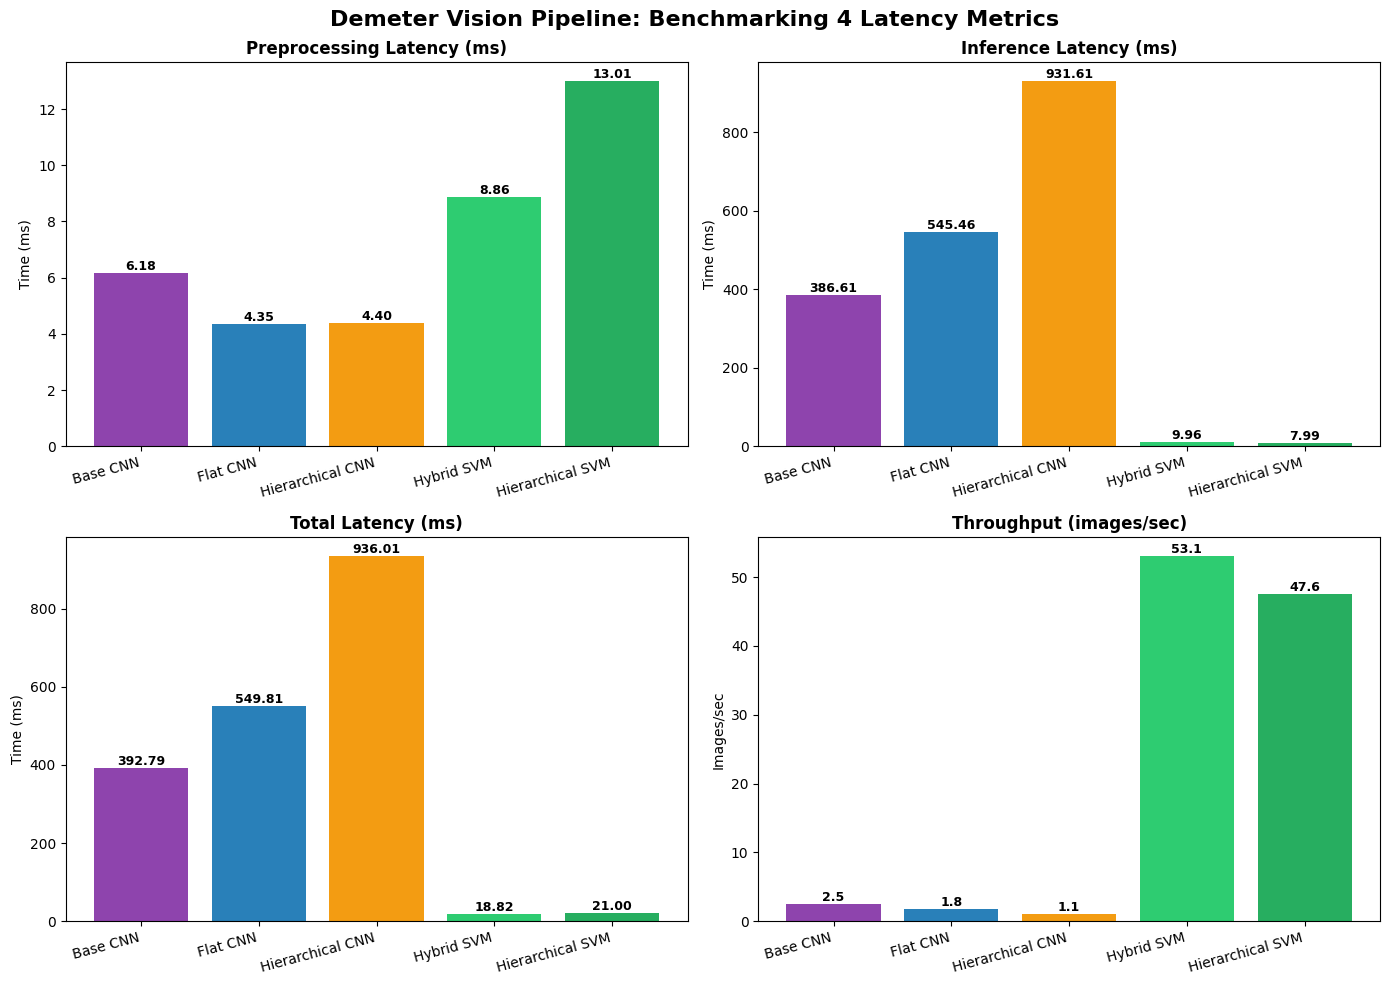

CONCLUSION: Monolithic Hybrid SVM is 29.21x faster than Flat CNN.
CONCLUSION: Hierarchical Hybrid SVM is 44.57x faster than Hierarchical CNN.


In [8]:
models_labels = [
    'Base CNN',
    'Flat CNN',
    'Hierarchical CNN',
    'Hybrid SVM',
    'Hierarchical SVM'
]

prep_times = [base_cnn_avg_prep, flat_cnn_avg_prep, hier_cnn_avg_prep, svm_avg_prep, hier_svm_avg_prep]
inf_times = [base_cnn_avg_inf, flat_cnn_avg_inf, hier_cnn_avg_inf, svm_avg_inf, hier_svm_avg_inf]
total_times = [base_cnn_avg_time, flat_cnn_avg_time, hier_cnn_avg_time, svm_avg_time, hier_svm_avg_time]
throughputs = [base_cnn_throughput, flat_cnn_throughput, hier_cnn_throughput, svm_throughput, hier_svm_throughput]

# Create DataFrame
df_metrics = pd.DataFrame({
    'Model': models_labels,
    'Preprocessing (ms)': prep_times,
    'Inference (ms)': inf_times,
    'Total Latency (ms)': total_times,
    'Throughput (img/sec)': throughputs
})
print("\n" + "="*60)
print("           SUMMARY OF 4 LATENCY METRICS")
print("="*60)
print(df_metrics.to_string(index=False))
print("="*60)

# Plot the 4 timing metrics in a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#8e44ad', '#2980b9', '#f39c12', '#2ecc71', '#27ae60']

# 1. Preprocessing Time
axs[0, 0].bar(models_labels, prep_times, color=colors)
axs[0, 0].set_title('Preprocessing Latency (ms)', fontsize=12, fontweight='bold')
axs[0, 0].set_ylabel('Time (ms)')
for bar in axs[0, 0].patches:
    axs[0, 0].annotate(f"{bar.get_height():.2f}", (bar.get_x() + bar.get_width()/2., bar.get_height()),
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Inference Time
axs[0, 1].bar(models_labels, inf_times, color=colors)
axs[0, 1].set_title('Inference Latency (ms)', fontsize=12, fontweight='bold')
axs[0, 1].set_ylabel('Time (ms)')
for bar in axs[0, 1].patches:
    axs[0, 1].annotate(f"{bar.get_height():.2f}", (bar.get_x() + bar.get_width()/2., bar.get_height()),
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Total Time
axs[1, 0].bar(models_labels, total_times, color=colors)
axs[1, 0].set_title('Total Latency (ms)', fontsize=12, fontweight='bold')
axs[1, 0].set_ylabel('Time (ms)')
for bar in axs[1, 0].patches:
    axs[1, 0].annotate(f"{bar.get_height():.2f}", (bar.get_x() + bar.get_width()/2., bar.get_height()),
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Throughput
axs[1, 1].bar(models_labels, throughputs, color=colors)
axs[1, 1].set_title('Throughput (images/sec)', fontsize=12, fontweight='bold')
axs[1, 1].set_ylabel('Images/sec')
for bar in axs[1, 1].patches:
    axs[1, 1].annotate(f"{bar.get_height():.1f}", (bar.get_x() + bar.get_width()/2., bar.get_height()),
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

for ax in axs.flat:
    ax.set_xticklabels(models_labels, rotation=15, ha='right')

plt.suptitle('Demeter Vision Pipeline: Benchmarking 4 Latency Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('latency_comparison.png', dpi=300)
plt.show()

# Print detailed speedup conclusions
speedup_base = flat_cnn_avg_time / svm_avg_time if svm_avg_time else 0
speedup_hier = hier_cnn_avg_time / hier_svm_avg_time if hier_svm_avg_time else 0
print(f"CONCLUSION: Monolithic Hybrid SVM is {speedup_base:.2f}x faster than Flat CNN.")
print(f"CONCLUSION: Hierarchical Hybrid SVM is {speedup_hier:.2f}x faster than Hierarchical CNN.")